<a href="https://colab.research.google.com/github/devesssi/AutoGrad-Engine/blob/main/Autograd_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [ ]:
def f(x):
  return 3*x**2-4*x+5

In [ ]:
f(3.0)

20.0

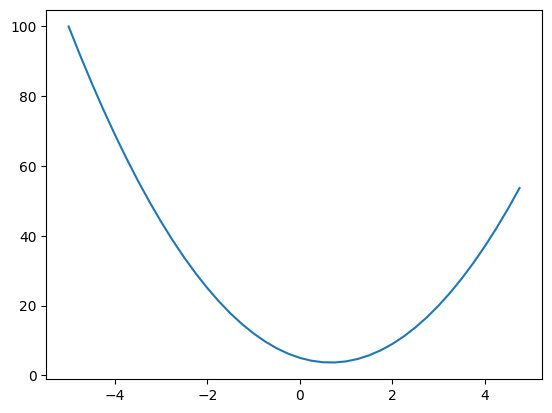

In [ ]:

xs = np.arange(-5 ,5 , 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
#defination of derivative is h tends to Zero f(x+h) + f(x)
h = 0.000001
x = 2/3
(f(x+h)-f(x))/h

2.999378523327323e-06

In [ ]:
class Value:

  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __truediv__(self, other): # self / other
    return self * other**-1

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __radd__(self, other): # other + self
    return self + other

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')

    def _backward():
      self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
    out._backward = _backward

    return out


  def backward(self):

    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [ ]:
a = Value(5.0 , label = 'a')
b = Value(2.0, label= 'b')
c = Value(6.0, label='c')
d = a+b*c
# a-b*b+a

In [ ]:

d._prev
d._op


'+'

In [ ]:
import graphviz

# Create a Directed Graph
dot = graphviz.Digraph(comment='The Round Table')
dot.comment
dot.node('A', 'King Arthur')
dot.node('B', 'Sir Bedevere the Wise')
dot.node('L', 'Sir Lancelot the Brave')
dot.edges(['AB', 'AL'])
dot.edge('B', 'L', constraint='false')

# Simply place the object name at the end of the cell to render

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
a = Value(5.0 , label = 'a')
b = Value(2.0, label= 'b')
c = Value(6.0, label='c')
d = a+b;d.label = 'd'
e =c ; e.label= 'e'
l = d*e ; l.label = 'l'

In [ ]:
a = Value(2.0 , label = 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label='c')
e = a*b;e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f ; L.label = 'L'
L1 = L.data

In [ ]:
L.grad = 1

In [ ]:
d.grad = -2
f.grad = 4

In [ ]:
e.grad = -2
c.grad = -2

gradient of d wrt l

dL/dd ? f
L = d*f

by defination of derivative
(f(x+h)-f(h))/h
(d+h*f - d*f)/h
((d+h-d)f)/h
h*f/h ==>f

dd/dc ? 1
dd/de ? 1
d = c+e
(c+h+e -c-e)/h
h/h =1




dl/dc ?
dl/dd *dd/dc
(-2)*1
-2

dl/de ?
dl/dd *dd/de
(-2)*1


dl/da ?
dl/db ?

de/da  = b.data
de/db = a.data

e = a*b

dl/de *de/da
(-2)*(-3) = 6

dl/da * de/db
(-2)* (2) = -4


derivative of tanh = 1- sqr(tanh(x))

In [ ]:
a.grad = 6
b.grad = -4

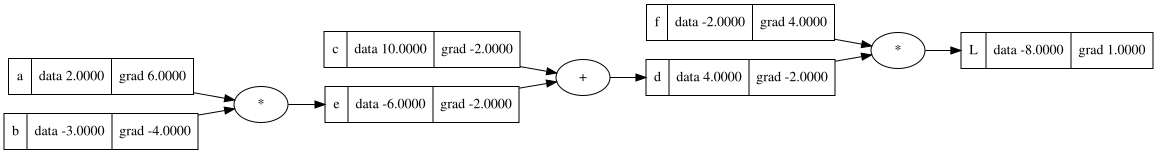

In [ ]:
draw_dot(L)

In [ ]:
def grad():
  h = 0.001
  a = Value(2.0 , label = 'a')
  b = Value(-3.0, label= 'b')
  c = Value(10.0, label='c')
  e = a*b;e.label = 'e'
  d = e+c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f ; L.label = 'L'
  L1 = L.data

  a = Value(2.0 , label = 'a')
  b = Value(-3.0, label= 'b')
  b.data +=h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e+c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d*f ; L.label = 'L'
  L2 = L.data


  print((L2-L1)/h)

grad()




-3.9999999999995595


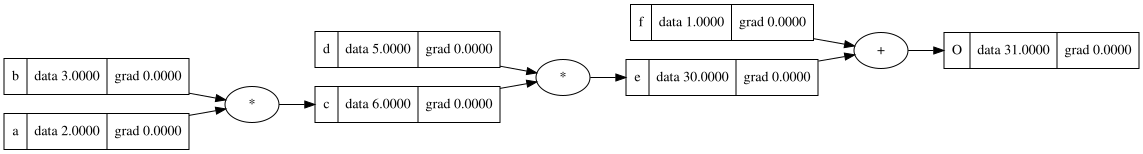

In [ ]:
a = Value(2 , label='a')
b = Value(3, label= 'b')
c = a*b ; c.label= 'c'
d = Value(5, label= 'd')
e = c*d; e.label = 'e'
f = Value(1, label= 'f')
O = e+f ; O.label = 'O'

draw_dot(O)

In [ ]:
O.grad = 1
# topo logical order from left to right ..
topo = []
visited = set()

def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(O)

In [ ]:
O._prev

{Value(data=1), Value(data=30)}

In [ ]:
topo

[Value(data=1),
 Value(data=2),
 Value(data=3),
 Value(data=6),
 Value(data=5),
 Value(data=30),
 Value(data=31)]

In [ ]:
for node in reversed(topo):
  node._backward()

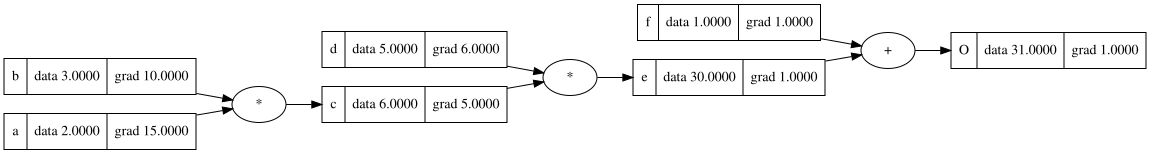

In [ ]:
draw_dot(O)

### Demonstration of New Operations and `backward()`

Let's create a new computational graph that utilizes some of the newly added operations, such as exponentiation (`**`) and division (`/`), and then run the `backward()` method to compute gradients.


The Unique Function: Each node holds its own unique _backward function that remembers its exact parent nodes.The Topo Order: The topological sort (topo) determines the exact sequence in which those unique functions must be executed.

In [ ]:
import math

a = Value(3.0, label='a')
b = Value(2.0, label='b')
c = a**2           # Using __pow__
c.label = 'c'
d = c / b          # Using __truediv__
d.label = 'd'
e = -d             # Using __neg__ (which uses __mul__ with -1)
e.label = 'e'
f = Value(5.0, label='f')
g = e + f          # Using __add__
g.label = 'g'
h = g.tanh()       # Using tanh
h.label = 'h'
i = Value(0.5, label='i')
L = h * i          # Final output, using __mul__
L.label = 'L'

print(f"Final value of L: {L.data}")

Final value of L: 0.23105857863000487


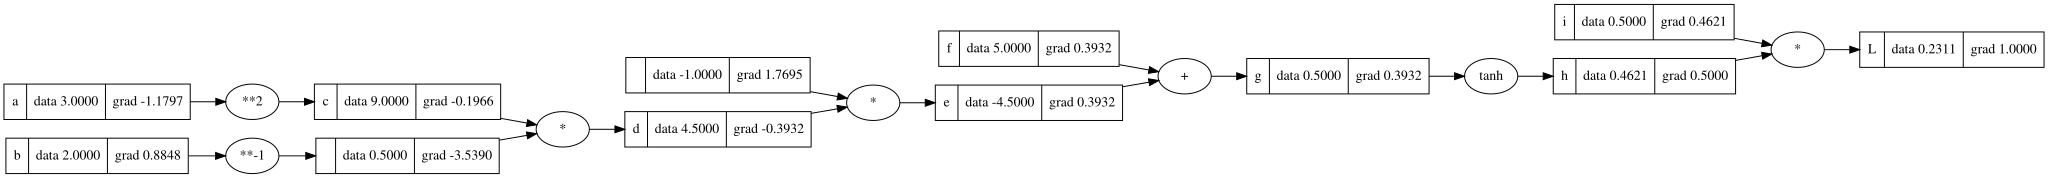

In [ ]:
# Perform backward pass to compute gradients
L.backward()

# Visualize the graph with computed gradients
draw_dot(L)